<a href="https://colab.research.google.com/github/arun-arunisto/PyTorch-Tutorial/blob/main/Tutorial_7_PyTorch_Training_MLP_on_Fashion_MNIST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fashion MNIST Classification using PyTorch

The Fashion MNIST dataset is included in `torchvision.datasets` and can easily be imported and loaded. Using this dataset, we will demonstrate how to work with image data that represents ten different classes of clothing items and how to develop a network architecture that includes ten neurons whose outputs represent the probability of the classes.

<img src="https://www.dropbox.com/scl/fi/dwxxxfuitptyqj1phxzm3/pytorch-cnn-based-classification-model-with-fashion-mnist_02-1.jpg?rlkey=ao3t3riq0npt6j79vvlp97qhz&st=0bwpnki2&dl=1" width=850>



## Importing Dependencies

In [1]:
# To view Model Summary
!pip install -q torchinfo

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary

import torchvision
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import random
import time

%matplotlib inline

## Setting seed for reproducibility

In PyTorch, setting a seed is like making sure you always use the exact same recipe and ingredients. It helps your computer get the same results every time you run your code, even if some things (like shuffling data or random numbers) usually change.


In [3]:
def set_seeds():
    # set random seed value
    SEED_VALUE = 42

    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)
    # Fix seed to make training deterministic.
    if torch.cuda.is_available():
       torch.cuda.manual_seed(SEED_VALUE)
       torch.cuda.manual_seed_all(SEED_VALUE)
       torch.backends.cudnn.deterministic = True
       torch.backends.cudnn.benchmark = True

set_seeds()

The Fashion MNIST dataset can be easily downloaded with torchvision.datasets and contains 70,000 images partitioned into 60,000 for training and 10,000 for test. We will perform validation and final prediction on the test dataset.

When working with images, we can use pixel intensities as features by flattening a 28x28 image into a 1D array of 784 values. We also normalize pixel values to [0,1] for better training. This is a simple approach.

In [4]:
#Convert to Tensors and Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # mean, std
])

In [5]:
# Download and load the training data
train_set = datasets.FashionMNIST(root = "F_MNIST_data", download = True, train = True, transform = transform)
val_set = datasets.FashionMNIST(root = "F_MNIST_data", download = True, train = False, transform = transform) #Test set

100%|██████████| 26.4M/26.4M [00:01<00:00, 22.2MB/s]


Extracting F_MNIST_data/FashionMNIST/raw/train-images-idx3-ubyte.gz to F_MNIST_data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 334kB/s]


Extracting F_MNIST_data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to F_MNIST_data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 6.22MB/s]


Extracting F_MNIST_data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to F_MNIST_data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 6.81MB/s]

Extracting F_MNIST_data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to F_MNIST_data/FashionMNIST/raw



In [6]:
print("Total Train Images: ", len(train_set))
print("Total Val Images: ", len(val_set))

Total Train Images:  60000
Total Val Images:  10000


To avoid the MLP network from learning the sequence pattern in the dataset we will shuffle the train dataset. A batch size is determined based on the compute resource available. As this is a relatively less compute intensive training we can set the `batch_size = 64`.

### **General Guideline Based on GPU VRAM**
| GPU Memory | Recommended `batch_size` |
|------------|--------------------------|
| 4GB        | 8 – 16  |
| 8GB        | 16 – 32  |
| 12GB       | 32 – 64  |
| 24GB+      | 128 – 256+ |

In [7]:
train_loader = torch.utils.data.DataLoader(train_set, shuffle = True, batch_size = 64)
val_loader = torch.utils.data.DataLoader(val_set, shuffle = False, batch_size = 64)

In [8]:
# Fashion MNIST classes for index mapping
#class to idx mapping
class_mapping = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"  }

## Dataset Visualization

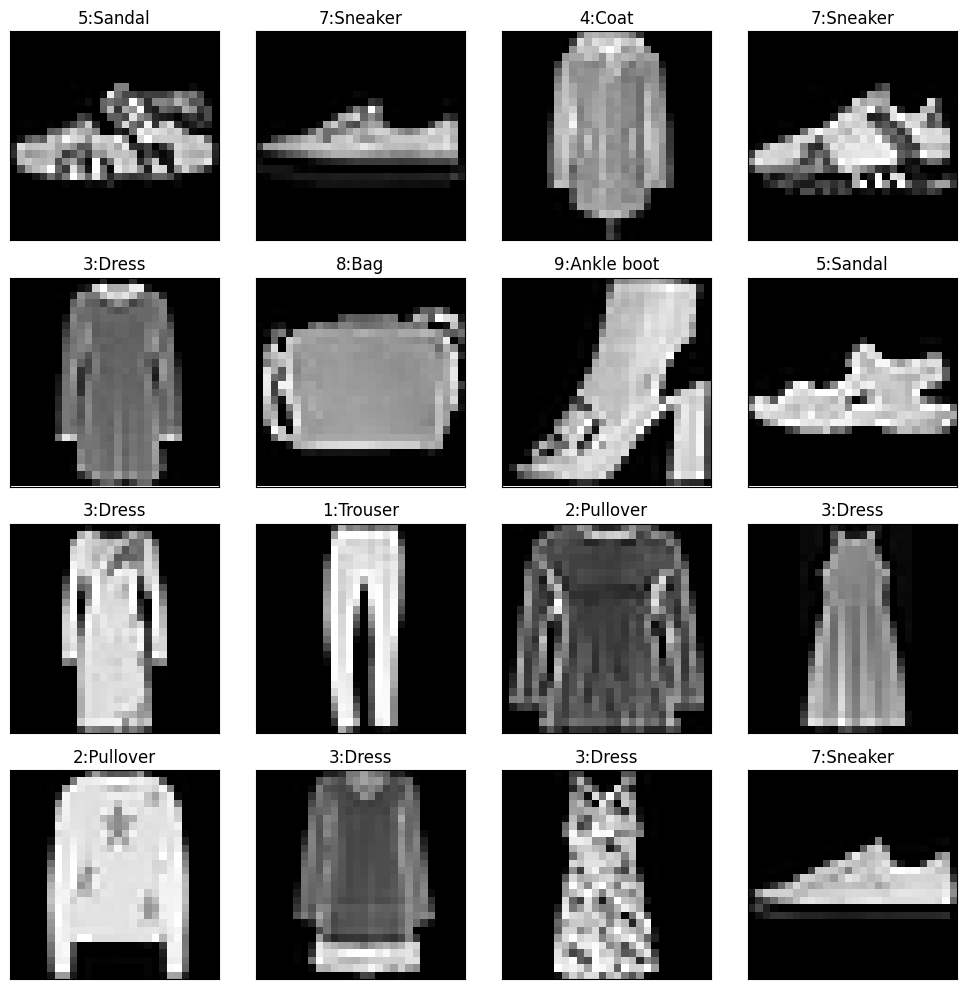

In [9]:
def visualize_images(trainloader, num_images=20):
    fig = plt.figure(figsize=(10, 10))

    # Iterate over the first batch
    images, labels = next(iter(trainloader))

    #To calculate the number of rows and columns for subplots
    num_rows = 4
    num_cols = int(np.ceil(num_images / num_rows))

    for idx in range(min(num_images, len(images))):
      image, label = images[idx], labels[idx]

      ax = fig.add_subplot(num_rows, num_cols, idx+1, xticks=[], yticks=[])
      ax.imshow(np.squeeze(image), cmap="gray")
      ax.set_title(f"{label.item()}:{class_mapping[label.item()]}")

    fig.tight_layout()
    plt.show()

visualize_images(train_loader, num_images=16)

## Model Architecture

The network architecture shown below has multiple layers. An input layer, five hidden layers, and an output layer. There are several things to note about this architecture.

1. **Input Data**: The image input data is pre-processed (flattened) from a 2-Dimensional array `[28x28]` to 1-Dimensional vector of length `[784x1]` where the elements in this input vector are the normalized pixel intensities.
2. **Hidden Layers**: We have five hidden layers that contain some number of neurons (that we need to specify). Each of the neurons in these layers has a non-linear activation function (e.g., **ReLU**, Sigmoid, etc.).
3. **Output Layer**: We now have ten neurons in the output layer to represent the ten different classes (cloth items: 0 to 9), instead of a single neuron as in the regression example.
4. **Dense Layers**: All the layers in the network are fully connected, meaning that each neuron in a given layer is fully connected (or dense) to each of the neurons in the previous layer. The **weights** associated with each layer are represented in bold to indicate that these are matrices that contain each of the weights for all the connections between adjacent layers in the network.
5. **Softmax Function**: The values from each of the neurons in the output layer are pased through a `log_softmax()` function to produce a probability score for each of the ten cloth items in the dataset.

6. **Network Output**: The network output ($y’$), is a vector of length ten, that contains the probabilities of each output neuron. Predicting the class label simply requires passing ($y'$) through the `argmax` function to determine the index of the predicted label.
6. **Loss Function**: The loss function used is **Negative Log Likelihood Loss**. It is computed from the ground truth labels ($y$) and the output log probabilities of the network ($y'$). Note that $y$ and $y'$ are both matrices whose shape is `(Bacth Size, Num Classes)`.

Although the diagram looks quite a bit different from the single-layer perceptron in the linear regression example, it is fundamentally very similar in terms of the processing that takes place during training and prediction. We still compute a loss based on the predicted output of the network and the ground truth label of the inputs. Backpropagation is used to compute the gradient of the loss with respect to the weights in the network. An Adam optimizer is used to update the weights in the neural network.

<img src='https://www.dropbox.com/scl/fi/56ks2wo5pem1m58djqsi8/MLP-with-Fashion-MNIST-Pipeline.png?rlkey=b7is8m2cz222fa6x88px2ll79&st=qvlv5i5f&dl=1' align='center' width='1000'>

## Multi Layer Perceptron (MLP) Model Implementation

The following defines an MLP (Multi-Layer Perceptron) model for classifying images into 10 classes using PyTorch nn Module. The model consists of five fully connected layers with ReLU activations, batch normalization, and dropout for regularization. The input layer processes 28x28 images (flattened to 784 features), and the output layer uses a log-softmax activation function to produce probabilities for the 10 classes.

Here we use log-softmax at the output layers, as Negative Log Likelihood Loss expects the model's outputs in terms of log probabilities. Dropout is used to prevent overfitting by randomly setting some of the activations to zero during training, and this is compensated by a scale factor to maintain the overall sum of activations.

In [11]:
class MLP(nn.Module):
    """
    The code defines a class called MLP that inherits from nn.Module, which is PyTorch’s base class for all neural network models.
    This inheritance gives the class access to PyTorch’s built-in functionality, like parameter tracking and forward-pass mechanics.
    """
    def __init__(self, num_classes):
        """
        __init__(self, num_classes): This is the constructor, called when you create an instance of the model (e.g., mlp_model = MLP(num_classes=10)).
        It sets up the network’s architecture.
        The num_classes parameter determines the number of output classes (10 here, suggesting a dataset like MNIST with digits 0-9).
        """
        super().__init__()
        """
        super().__init__(): This calls the parent class (nn.Module) constructor to initialize it properly.
        """
        self.fc0 = nn.Linear(784, 512)
        """
        self.fc0 = nn.Linear(784, 512): First fully connected layer.
        Takes a flattened input of 784 features (e.g., 28x28 pixels from an MNIST image) and outputs 512 features.
        """
        self.bn0 = nn.BatchNorm1d(512)
        """
        self.bn0 = nn.BatchNorm1d(512): Batch normalization for the 512 outputs.
        This normalizes activations across the batch, stabilizing training.
        """
        self.fc1 = nn.Linear(512, 256)
        """
        self.fc1 = nn.Linear(512, 256): Second layer, reducing from 512 to 256 features.
        """
        self.bn1 = nn.BatchNorm1d(256)
        """
        self.bn1 = nn.BatchNorm1d(256): Batch normalization for the 256 outputs.
        """
        self.fc2 = nn.Linear(256, 128)
        """
        self.fc2 = nn.Linear(256, 128): Third layer, reducing from 256 to 128 features.
        """
        self.bn2 = nn.BatchNorm1d(128)
        """
        self.bn2 = nn.BatchNorm1d(128): Batch normalization for the 128 outputs.
        """
        self.fc3 = nn.Linear(128, 64)
        """
        self.fc3 = nn.Linear(128, 64): Fourth layer, reducing from 128 to 64 features.
        """
        self.bn3 = nn.BatchNorm1d(64)
        """
        self.bn3 = nn.BatchNorm1d(64): Batch normalization for the 64 outputs.
        """
        self.fc4 = nn.Linear(64,num_classes)
        """
        self.fc4 = nn.Linear(64, num_classes): Final layer, mapping 64 features to num_classes outputs (10 here).
        """
        self.dropout = nn.Dropout(p=0.3)
        """
        self.dropout = nn.Dropout(p=0.3): Dropout layer with a 30% chance of zeroing out activations during training.
        This helps prevent overfitting by forcing the network to not rely too heavily on any single neuron.
        """

    def forward(self, x):
        """
        The forward method defines how data flows through the network. It takes an input tensor x (e.g., a batch of images) and returns the output (class probabilities).
        """
        #Flatten the input tensor
        x = x.view(x.shape[0], -1) #(B,784)  --> 28x28 = 784
        """
        x = x.view(x.shape[0], -1): Flattens the input.
          * x.shape[0] is the batch size (e.g., 32 images).
          * -1 tells PyTorch to figure out the remaining dimension, turning each image (assumed 28x28) into a 784-element vector. So, shape goes from (B, 1, 28, 28) (batch, channels, height, width) to (B, 784).
        """
        # First fully connected layer with ReLU, batch norm, and dropout
        x = F.relu(self.bn0(self.fc0(x)))
        x = self.dropout(x)
        """
        Layer 1:
          * self.fc0(x): Linear transformation (784 → 512).
          * self.bn0(...): Normalizes the 512 outputs.
          * F.relu(...): Applies ReLU activation (sets negative values to 0, adding nonlinearity).
          * self.dropout(x): Drops 30% of the activations (only during training).
        """
        x = F.relu(self.bn1(self.fc1(x)))
        """
        Layer 2:
          * self.fc1(x): Linear (512 → 256).
          * self.bn1(...): Batch norm.
          * F.relu(...): ReLU. (No dropout here.)
        """
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        """
        Layer 3:
          * self.fc2(x): Linear (256 → 128).
          * self.bn2(...): Batch norm.
          * F.relu(...): ReLU.
          * self.dropout(x): Dropout again.
        """
        # Output layer with softmax activation
        x = F.relu(self.bn3(self.fc3(x)))
        """
        Layer 4:
          * self.fc3(x): Linear (128 → 64).
          * self.bn3(...): Batch norm.
          * F.relu(...): ReLU.
        """
        x = F.log_softmax(self.fc4(x), dim = 1)
        """
        Output Layer:
          * self.fc4(x): Linear (64 → num_classes, here 10).
          * F.log_softmax(x, dim=1): Applies log-softmax along dimension 1 (across the class scores). This outputs log probabilities, handy for classification with a loss like negative log-likelihood.
        """
        return x

# Instantiate the model.
mlp_model = MLP(num_classes = 10)
"""
Creates an instance of the MLP with 10 output classes.
At this point, the model’s architecture is set, and it’s ready to be trained or used for inference once moved to a device (e.g., GPU) and paired with an optimizer and loss function.
"""

'\nCreates an instance of the MLP with 10 output classes. \nAt this point, the model’s architecture is set, and it’s ready to be trained or used for inference once moved to a device (e.g., GPU) and paired with an optimizer and loss function.\n'

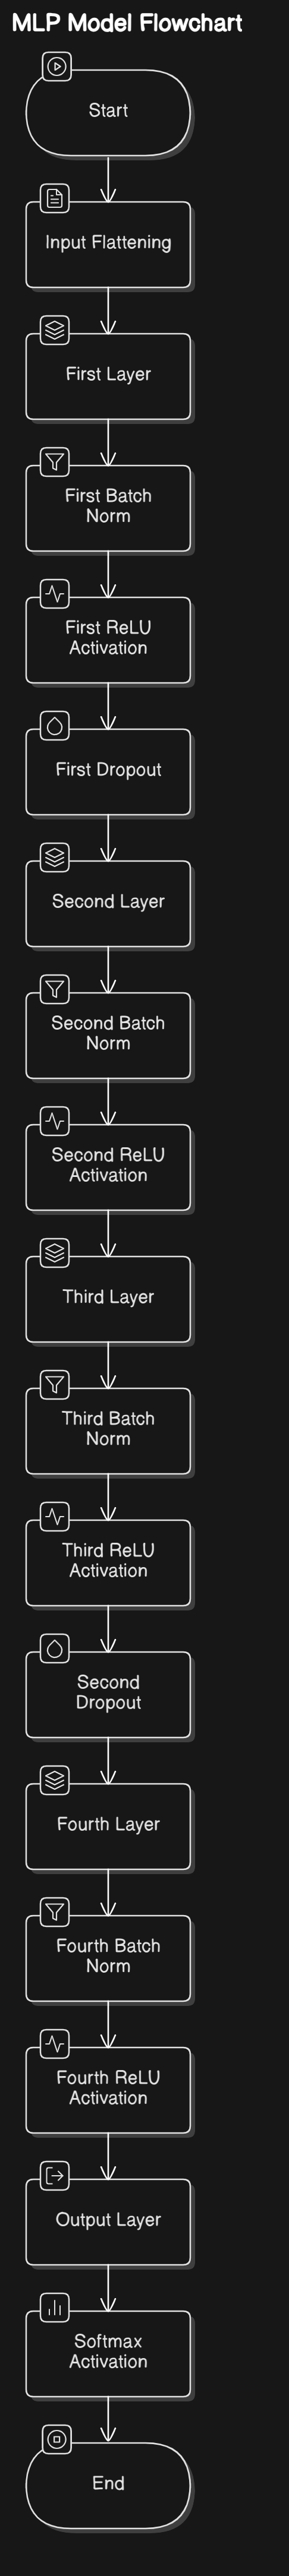

Let's look at the parameters and the output shape after each layers.

In [12]:
#A dummy input size of (B,C,H,W) = (1,1,28,28) is passed.
print(summary(mlp_model, input_size = (1,1,28,28), row_settings = ["var_names"]))
# Display the model summary.

Layer (type (var_name))                  Output Shape              Param #
MLP (MLP)                                [1, 10]                   --
├─Linear (fc0)                           [1, 512]                  401,920
├─BatchNorm1d (bn0)                      [1, 512]                  1,024
├─Dropout (dropout)                      [1, 512]                  --
├─Linear (fc1)                           [1, 256]                  131,328
├─BatchNorm1d (bn1)                      [1, 256]                  512
├─Linear (fc2)                           [1, 128]                  32,896
├─BatchNorm1d (bn2)                      [1, 128]                  256
├─Dropout (dropout)                      [1, 128]                  --
├─Linear (fc3)                           [1, 64]                   8,256
├─BatchNorm1d (bn3)                      [1, 64]                   128
├─Linear (fc4)                           [1, 10]                   650
Total params: 576,970
Trainable params: 576,970
Non-trainable

## Training Configuration

In [14]:
criterion = F.nll_loss #Negative Log Likelihood Loss
optimizer = optim.Adam(mlp_model.parameters(), lr = 1e-2) #0.01
num_epochs = 1 # for sample using 1 need to use more for better training and results
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Model Training

In [15]:
def train(model, trainloader, criterion, optimizer,DEVICE):
    model.train()
    """
    model.train(): Switches the model to training mode.
    This is key because layers like dropout and batch norm behave differently during training (e.g., dropout is active, batch norm updates its stats) versus evaluation.
    """
    model.to(DEVICE)
    """
    model.to(DEVICE): Moves the model to the specified device (e.g., GPU).
    This ensures computations happen where you want them.
    """
    running_loss = 0 #Accumulates the loss across batches.
    correct_predictions = 0 #Counts correct predictions for accuracy.
    total_samples = 0 #Tracks the total number of samples processed.

    for images, labels in trainloader:
        images,labels = images.to(DEVICE),labels.to(DEVICE)
        """
        images, labels = images.to(DEVICE), labels.to(DEVICE): Moves the batch data to the same device as the model (e.g., GPU). This keeps everything aligned for computation.
        """
        optimizer.zero_grad()
        """
        optimizer.zero_grad(): Clears the gradients from the previous step. In PyTorch, gradients accumulate by default, so you reset them before each new forward-backward pass.
        """
        outputs = model(images)
        """
        outputs = model(images): Runs the batch through the model (calls the forward method).
        For this MLP, this flattens the images, processes them through the layers, and outputs log-probabilities (e.g., shape (batch_size, 10) for 10 classes).
        """
        loss = criterion(outputs, labels)
        """
        loss = criterion(outputs, labels): Computes the loss between the model’s predictions (outputs) and the true labels.
        """
        loss.backward()
        """
        loss.backward(): Computes gradients of the loss with respect to the model’s parameters (backpropagation).
        These gradients tell the optimizer how to adjust weights.
        """
        optimizer.step()
        """
        optimizer.step(): Updates the model’s weights using the gradients and the optimizer’s rules
        """
        running_loss += loss.item()
        """
        running_loss += loss.item(): Adds the batch’s loss (a scalar) to the running total. .item() converts it from a tensor to a Python number.
        """
        _, predicted = torch.max(outputs.data, dim=1)
        """
        _, predicted = torch.max(outputs.data, dim=1): Gets the predicted class for each sample.
        torch.max finds the highest value along dimension 1 (the class dimension), returning values and indices; _ discards the values, predicted keeps the indices (class IDs).
        """
        total_samples += labels.size(0)
        """
        total_samples += labels.size(0): Adds the batch size (number of samples) to the total. labels.size(0) is the batch dimension.
        """
        correct_predictions += (predicted == labels).sum().item()
        """
        correct_predictions += (predicted == labels).sum().item(): Counts how many predictions match the labels.
        predicted == labels creates a boolean tensor, .sum() adds up the True values, and .item() converts it to a number.
        """

    avg_loss = running_loss / len(trainloader)
    """
    avg_loss = running_loss / len(trainloader): Computes the average loss over all batches. len(trainloader) is the number of batches in the epoch.
    """
    accuracy = 100 * correct_predictions / total_samples
    """
    accuracy = 100 * correct_predictions / total_samples: Calculates accuracy as a percentage: (correct predictions / total samples) × 100.
    """
    return avg_loss, accuracy

In [17]:
def validation(model, val_loader, criterion,DEVICE):
    model.eval()
    """
    model.eval(): Switches the model to evaluation mode.
    This disables training-specific behaviors like dropout (no neurons are dropped) and batch normalization (uses saved statistics instead of updating them).
    It ensures the model behaves consistently for inference.
    """
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images,labels = images.to(DEVICE),labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1) #(B, class_id)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    avg_loss = running_loss / len(val_loader)
    accuracy = 100 * correct_predictions / total_samples
    return avg_loss, accuracy

In [18]:
def main(model, trainloader, val_loader, epochs=5, DEVICE = "cuda"):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        train_loss, train_accuracy = train(model, trainloader, criterion, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, criterion, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1:0>2}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    # Plotting loss and accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

Epoch 01/10 - Train Loss: 0.5620, Train Accuracy: 80.01% - Val Loss: 0.4328, Val Accuracy: 84.15%
Epoch 02/10 - Train Loss: 0.4357, Train Accuracy: 84.39% - Val Loss: 0.3778, Val Accuracy: 86.11%
Epoch 03/10 - Train Loss: 0.3970, Train Accuracy: 85.82% - Val Loss: 0.3834, Val Accuracy: 86.00%
Epoch 04/10 - Train Loss: 0.3706, Train Accuracy: 86.62% - Val Loss: 0.3670, Val Accuracy: 86.85%
Epoch 05/10 - Train Loss: 0.3501, Train Accuracy: 87.41% - Val Loss: 0.3594, Val Accuracy: 86.75%
Epoch 06/10 - Train Loss: 0.3334, Train Accuracy: 87.84% - Val Loss: 0.3467, Val Accuracy: 87.23%
Epoch 07/10 - Train Loss: 0.3265, Train Accuracy: 87.95% - Val Loss: 0.3234, Val Accuracy: 88.16%
Epoch 08/10 - Train Loss: 0.3125, Train Accuracy: 88.78% - Val Loss: 0.3297, Val Accuracy: 87.89%
Epoch 09/10 - Train Loss: 0.2998, Train Accuracy: 89.05% - Val Loss: 0.3371, Val Accuracy: 87.24%
Epoch 10/10 - Train Loss: 0.2915, Train Accuracy: 89.36% - Val Loss: 0.3214, Val Accuracy: 88.40%


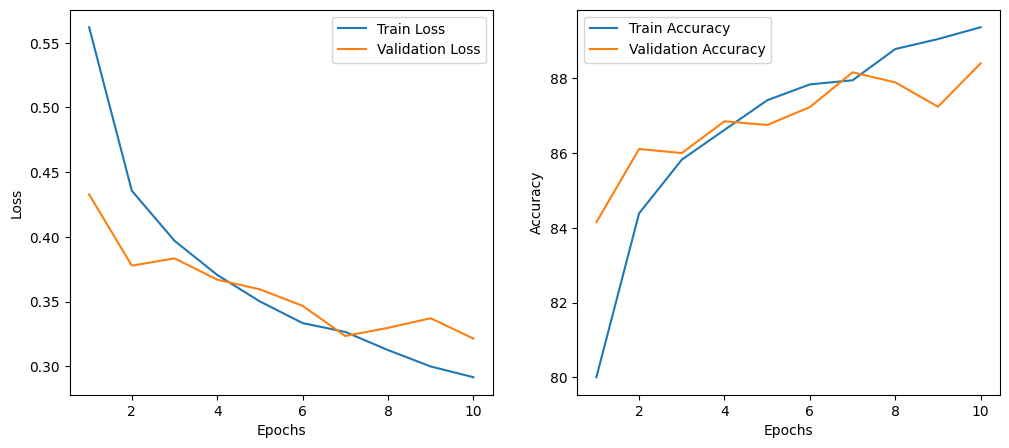

In [19]:
main(mlp_model, train_loader, val_loader, epochs = 10, DEVICE = DEVICE)

## Predicting the result

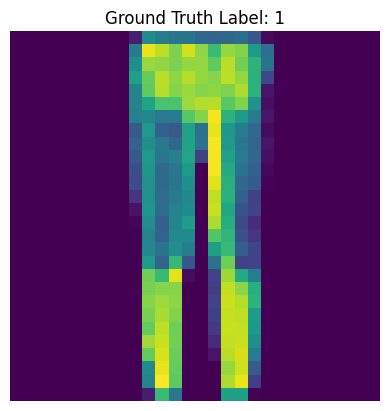

In [21]:
images, gt_labels = next(iter(val_loader))

rand_idx = random.choice(range(len(images)))

plt.imshow(images[rand_idx].squeeze())
plt.title("Ground Truth Label: " + str(int(gt_labels[rand_idx])), fontsize = 12)
plt.axis("off")
plt.show()

In [22]:
# Formatting
bold = f"\033[1m"
reset = f"\033[0m"

In [23]:
mlp_model.eval()

with torch.no_grad():
     batch_outputs = mlp_model(images.to(DEVICE))

prob_score_batch = batch_outputs.softmax(dim=1).cpu()

prob_score_test_image = prob_score_batch[rand_idx]
pred_cls_id = prob_score_test_image.argmax()

print("Predictions for each class on the test image:\n")

for idx, cls_prob in enumerate(prob_score_test_image):
    if idx == pred_cls_id:
       print(f"{bold}Class: {idx} - {class_mapping[idx]}, Probability: {cls_prob:.3f}{reset}")
    else:
       print(f"Class: {idx} - {class_mapping[idx]}, Probability: {cls_prob:.3f}")

Predictions for each class on the test image:

Class: 0 - T-shirt/top, Probability: 0.000
Class: 1 - Trouser, Probability: 1.000
Class: 2 - Pullover, Probability: 0.000
Class: 3 - Dress, Probability: 0.000
Class: 4 - Coat, Probability: 0.000
Class: 5 - Sandal, Probability: 0.000
Class: 6 - Shirt, Probability: 0.000
Class: 7 - Sneaker, Probability: 0.000
Class: 8 - Bag, Probability: 0.000
Class: 9 - Ankle boot, Probability: 0.000


## Confusion Matrix

A confusion matrix is a very common metric that is used to summarize the results of a classification problem. The information is presented in the form of a table or matrix where one axis represents the ground truth labels for each class, and the other axis represents the predicted lables from the network. The entries in the table represent the number of instances from an experiment (which are sometimes represented as percentages rather than counts). Generating a confusion matrix is accomplished by calling the confusion_matrix from sklearn.metrics, which takes two required arguments which are the list of ground truth labels and the associated predicted lables.

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

In [25]:
def prediction_batch(model, batch_inputs):
    model.eval()

    batch_outputs = model(batch_inputs)

    with torch.no_grad():
        batch_probs = batch_outputs.softmax(dim=1) #along num of classes dimension

    batch_cls_ids = batch_probs.argmax(dim=1)

    return batch_cls_ids.cpu()

In [26]:
val_target_labels = []
val_predicted_labels = []

for image_batch, target_batch in val_loader:
    image_batch = image_batch.to(DEVICE)

    batch_pred_cls_id = prediction_batch(mlp_model, image_batch)

    val_predicted_labels.append(batch_pred_cls_id)
    val_target_labels.append(target_batch)

val_target_labels = torch.cat(val_target_labels).numpy()
val_predicted_labels = torch.cat(val_predicted_labels).numpy()

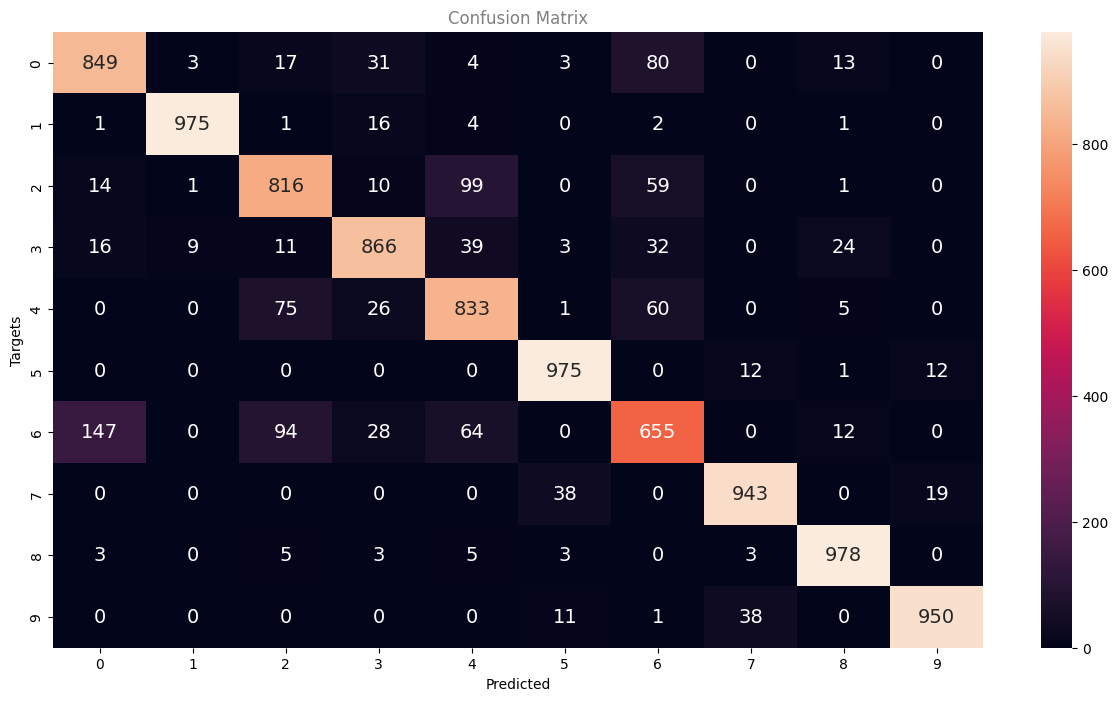

In [27]:
cm = confusion_matrix(y_true=val_target_labels, y_pred = val_predicted_labels)

plt.figure(figsize= [15,8])

# Plot the confusion matrix as a heatmap.
sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14})
plt.xlabel("Predicted")
plt.ylabel("Targets")
plt.title(f"Confusion Matrix", color="gray")
plt.show()